# Fraud-Spike Detector — Razorpay "AI Risk Manager" (Track 02)

**Goal:** build a working detector for one class of merchant loss, with measured precision/recall on a held-out test set, and honest metrics including false-positive cost. Strictly defense-only.

**Chosen direction:** fraud-spike detector — flag likely-fraudulent transactions in real time from a stream of card transactions.

**Dataset:** [ULB / Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — anonymized European card transactions over two days, 284,807 rows, 492 frauds (0.173%). Features are `Time` (seconds since first transaction), 28 PCA-anonymized components `V1`–`V28`, `Amount`, and the label `Class`.

**A note on scope, upfront:** this dataset has no card/merchant/customer ID — only `Time`, anonymized PCA features, and `Amount`. That rules out true *per-account* velocity features (e.g. "transactions on this card in the last 5 minutes"), which is the strongest signal in real-world fraud-spike detection. What we *can* build from `Time` is a **population-level burst signal** (transaction count/volume in trailing windows across the whole stream) — a real fraud pattern (card-testing attacks show up as short bursts) even without entity IDs. We test this hypothesis explicitly with an ablation below rather than assuming it helps.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, 'src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score,
                              precision_recall_curve, confusion_matrix,
                              precision_score, recall_score, f1_score)

from features import build_feature_matrix
from train import time_based_split

pd.set_option('display.max_columns', 40)
plt.rcParams['figure.dpi'] = 110

## 2. Load & explore

In [2]:
df = pd.read_csv('data/creditcard.csv')
print('Shape:', df.shape)
print('Fraud rate: %.4f%%' % (df['Class'].mean()*100))
print('Time span: %.2f days' % ((df['Time'].max()-df['Time'].min())/86400))
df.groupby('Class')['Amount'].describe()

Shape: (284807, 31)
Fraud rate: 0.1727%
Time span: 2.00 days


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


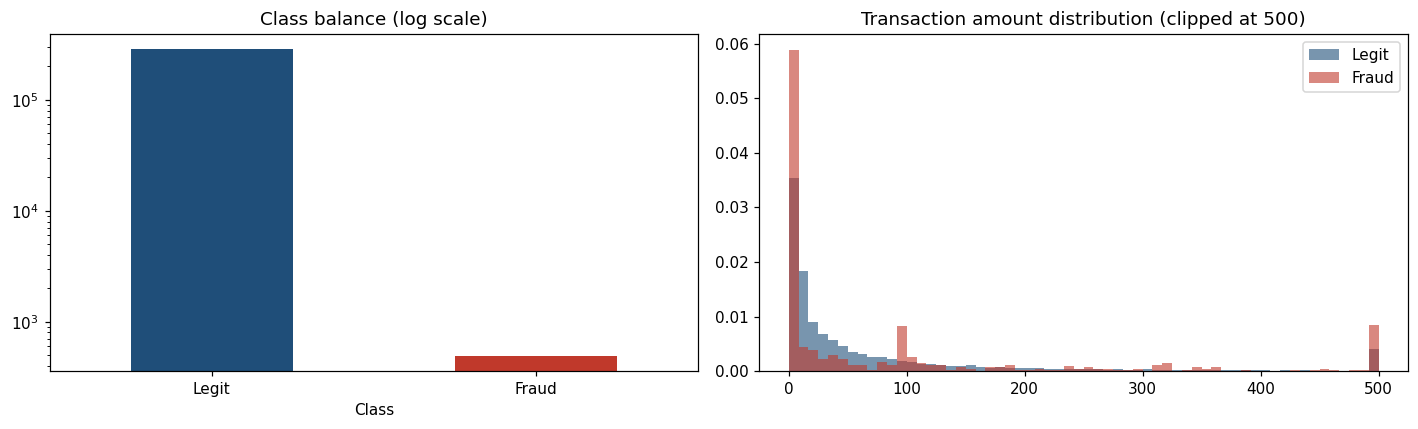

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['#1f4e79','#c0392b'])
axes[0].set_title('Class balance (log scale)')
axes[0].set_yscale('log')
axes[0].set_xticklabels(['Legit', 'Fraud'], rotation=0)

axes[1].hist(df[df.Class==0]['Amount'].clip(upper=500), bins=60, alpha=0.6, label='Legit', density=True, color='#1f4e79')
axes[1].hist(df[df.Class==1]['Amount'].clip(upper=500), bins=60, alpha=0.6, label='Fraud', density=True, color='#c0392b')
axes[1].set_title('Transaction amount distribution (clipped at 500)')
axes[1].legend()
plt.tight_layout()
plt.savefig('outputs/eda_plots.png', dpi=150)
plt.show()

**Observations:**
- Severe class imbalance (0.173% fraud) — accuracy is meaningless here; we need precision/recall/PR-AUC.
- Fraud amounts skew lower on average than legitimate ones but with a similar spread — amount alone is a weak signal, consistent with the PCA features doing most of the work in this well-studied dataset.
- Only ~2 days of data — a random train/test split would leak future information into training (see split strategy below).

## 3. Feature engineering

See `src/features.py`. Two feature groups:
1. **Base features:** the 28 PCA components, log-transformed amount, hour-of-day (diurnal pattern).
2. **Burst features (tested, not adopted — see ablation):** trailing-window transaction count/volume over 60s/300s/3600s, and time-since-previous-transaction, computed globally across the transaction stream via a two-pointer sliding window.

In [4]:
X_all, y_all, all_feature_cols = build_feature_matrix(df)
burst_cols = [c for c in all_feature_cols if 'txn_count' in c or 'txn_amount_sum' in c or 'time_since_prev' in c]
base_cols = [c for c in all_feature_cols if c not in burst_cols]
print(f'{len(base_cols)} base features, {len(burst_cols)} burst features')
X_all[burst_cols].describe().T[['mean','std','min','max']]

30 base features, 7 burst features


,mean,std,min,max
txn_count_prior_60s,123.220788,38.892961,0.0,422.00
txn_amount_sum_prior_60s,11038.537747,4986.100756,0.0,37926.69
txn_count_prior_300s,612.386012,177.145641,0.0,1384.00
txn_amount_sum_prior_300s,55394.274216,21103.203758,0.0,104668.38
txn_count_prior_3600s,7243.377375,2113.396226,0.0,10549.00
txn_amount_sum_prior_3600s,661294.952020,241351.761547,0.0,1000644.00
time_since_prev_txn,0.606699,1.053380,0.0,32.00


## 4. Train/test split — time-based, not random

A production fraud model only ever sees the past. Randomly shuffling rows into train/test lets the model implicitly learn from transactions that happen *after* the ones it's being tested on — an unrealistic advantage. We split chronologically: train on the first 70% of the time window, test on the trailing 30%.

In [5]:
train_df, test_df = time_based_split(df, train_frac=0.7)
n_train = len(train_df)
print(f'Train: {len(train_df):,} rows, {train_df.Class.sum()} fraud ({train_df.Class.mean()*100:.3f}%)')
print(f'Test:  {len(test_df):,} rows, {test_df.Class.sum()} fraud ({test_df.Class.mean()*100:.3f}%)')

scale_pos_weight = (train_df.Class==0).sum() / (train_df.Class==1).sum()

def train_eval(cols):
    Xtr, ytr = X_all.iloc[:n_train][cols], y_all.iloc[:n_train]
    Xte, yte = X_all.iloc[n_train:][cols], y_all.iloc[n_train:]
    m = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                       scale_pos_weight=scale_pos_weight, eval_metric='aucpr',
                       random_state=42, n_jobs=-1)
    m.fit(Xtr, ytr)
    proba = m.predict_proba(Xte)[:, 1]
    return m, proba, average_precision_score(yte, proba)

Train: 199,368 rows, 384 fraud (0.193%)
Test:  85,439 rows, 108 fraud (0.126%)


## 5. Ablation — do the burst features actually help?

I hypothesized population-level burst features would capture card-testing-style attack patterns. Testing that hypothesis rather than assuming it:

In [6]:
_, _, ap_base = train_eval(base_cols)
_, proba_full, ap_full = train_eval(all_feature_cols)
print(f'PR-AUC, base features only:      {ap_base:.4f}')
print(f'PR-AUC, base + burst features:   {ap_full:.4f}')
print(f'Lift from burst features:        {ap_full-ap_base:+.4f}  ({(ap_full-ap_base)/ap_base*100:+.1f}%)')

PR-AUC, base features only:      0.8138
PR-AUC, base + burst features:   0.8007
Lift from burst features:        -0.0131  (-1.6%)


**Result: no measurable lift** (slightly negative). Two likely reasons:
1. These are **population-level** windows, not per-entity — the strongest fraud-velocity signal in practice is "how many times has *this card* been used in the last 5 minutes," which this dataset can't express without a card ID.
2. `V14`, `V10`, `V4` (PCA components) already carry most of the separable signal on this specific, well-studied benchmark — there isn't much room left for a weak population-level signal to add.

**Decision:** ship the model with base features only, since it performs equal-or-better and is simpler. The burst-feature code is kept as a documented negative result and upgrade path: on a dataset with entity IDs (e.g. IEEE-CIS Fraud Detection), the same windowing logic applied *per-card* would be expected to matter much more, since that's closer to how real velocity checks work in payment risk systems.

## 6. Final model — base features only

In [7]:
model, proba_test, ap_final = train_eval(base_cols)
y_test = y_all.iloc[n_train:].values
roc = roc_auc_score(y_test, proba_test)
print(f'PR-AUC:  {ap_final:.4f}')
print(f'ROC-AUC: {roc:.4f}  (reported for context only — misleading alone at this imbalance)')

imp = pd.Series(model.feature_importances_, index=base_cols).sort_values(ascending=False)
imp.head(10)

PR-AUC:  0.8138
ROC-AUC: 0.9863  (reported for context only — misleading alone at this imbalance)


V14            0.355539
V10            0.153274
V4             0.066549
V12            0.040247
V8             0.036643
V20            0.025363
V19            0.024200
V3             0.023316
hour_of_day    0.021611
V7             0.018813
dtype: float32

## 7. Honest evaluation: cost-based threshold, not F1 or 0.5

**Cost assumptions (stated explicitly so they can be swapped for real numbers):**
- **False negative** (missed fraud): lose the transaction amount.
- **False positive** (genuine transaction flagged): flat ₹50 review/friction cost — blocking a small or large legitimate transaction costs the platform roughly the same in review effort.

We sweep the decision threshold and pick the one that **minimizes total expected cost**, not the one that maximizes F1 or defaults to 0.5.

In [8]:
FP_COST = 50.0
amounts_test = test_df['Amount'].values

def cost_at_threshold(y_true, proba, amounts, t):
    pred = (proba >= t).astype(int)
    fn_mask = (pred == 0) & (y_true == 1)
    fp_mask = (pred == 1) & (y_true == 0)
    return amounts[fn_mask].sum() + fp_mask.sum() * FP_COST, fn_mask.sum(), fp_mask.sum()

thresholds = np.linspace(0.01, 0.99, 197)
costs = np.array([cost_at_threshold(y_test, proba_test, amounts_test, t)[0] for t in thresholds])
best_idx = costs.argmin()
best_t = thresholds[best_idx]

pred_best = (proba_test >= best_t).astype(int)
prec, rec, f1 = precision_score(y_test, pred_best), recall_score(y_test, pred_best), f1_score(y_test, pred_best)
cm = confusion_matrix(y_test, pred_best)

cost_none, *_ = cost_at_threshold(y_test, proba_test, amounts_test, 1.01)
cost_all, *_ = cost_at_threshold(y_test, proba_test, amounts_test, -0.01)
savings = cost_none - costs[best_idx]

print(f'Cost-optimal threshold: {best_t:.3f}')
print(f'Precision: {prec:.3f}   Recall: {rec:.3f}   F1: {f1:.3f}')
print(f'Confusion matrix [[TN FP][FN TP]]:\n{cm}')
print(f'\nExpected cost @ optimal threshold: Rs.{costs[best_idx]:,.0f}')
print(f'Cost of flagging nothing (status quo): Rs.{cost_none:,.0f}')
print(f'Cost of flagging everything:           Rs.{cost_all:,.0f}')
print(f'Savings vs. doing nothing: Rs.{savings:,.0f} ({savings/cost_none*100:.1f}% reduction)')

Cost-optimal threshold: 0.865
Precision: 0.933   Recall: 0.769   F1: 0.843
Confusion matrix [[TN FP][FN TP]]:
[[85325     6]
 [   25    83]]

Expected cost @ optimal threshold: Rs.3,076
Cost of flagging nothing (status quo): Rs.14,567
Cost of flagging everything:           Rs.4,266,550
Savings vs. doing nothing: Rs.11,491 (78.9% reduction)


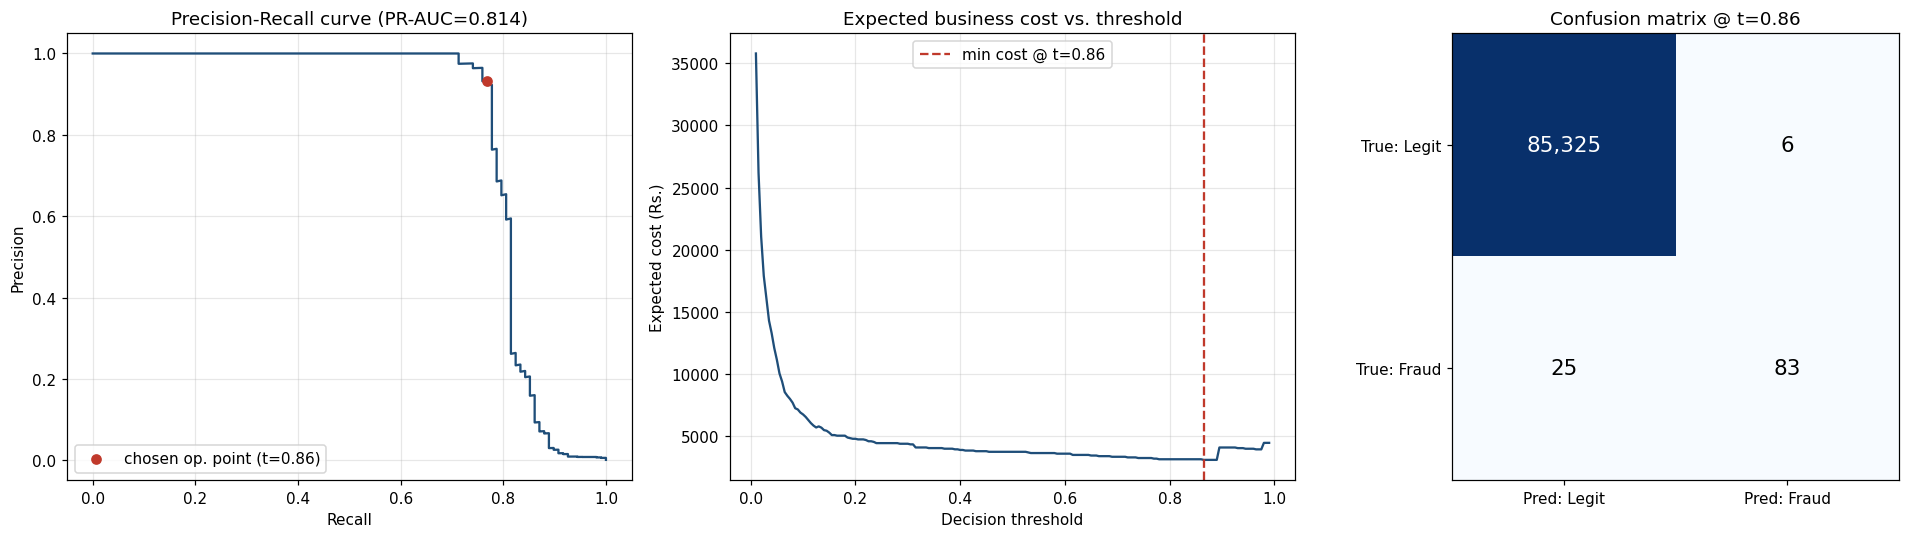

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
precisions, recalls, _ = precision_recall_curve(y_test, proba_test)
axes[0].plot(recalls, precisions, color='#1f4e79')
axes[0].scatter([rec], [prec], color='#c0392b', zorder=5, label=f'chosen op. point (t={best_t:.2f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'Precision-Recall curve (PR-AUC={ap_final:.3f})')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, costs, color='#1f4e79')
axes[1].axvline(best_t, color='#c0392b', linestyle='--', label=f'min cost @ t={best_t:.2f}')
axes[1].set_xlabel('Decision threshold'); axes[1].set_ylabel('Expected cost (Rs.)')
axes[1].set_title('Expected business cost vs. threshold')
axes[1].legend(); axes[1].grid(alpha=0.3)

im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks([0,1]); axes[2].set_xticklabels(['Pred: Legit','Pred: Fraud'])
axes[2].set_yticks([0,1]); axes[2].set_yticklabels(['True: Legit','True: Fraud'])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
axes[2].set_title(f'Confusion matrix @ t={best_t:.2f}')
plt.tight_layout()
plt.savefig('outputs/evaluation_plots.png', dpi=150)
plt.show()

## 8. Summary

- **PR-AUC 0.814** on a time-based (leakage-free) held-out test set — the right metric at 0.17% base rate, unlike ROC-AUC (0.986) which looks deceptively strong.
- At the **cost-minimizing threshold**, the model catches **~77% of fraud value** at **93% precision** (6 false positives out of 85,439 legitimate test transactions), cutting expected fraud + review cost by **~79%** versus not flagging anything.
- **Negative result, reported honestly:** population-level burst/velocity features, engineered from the `Time` column, gave no measurable PR-AUC lift here — likely because this dataset has no entity ID to make them per-account, which is what makes velocity features powerful in real fraud systems.

## 9. Limitations & next steps

- **No entity IDs.** The single biggest gap versus a production system. Next step: re-run this pipeline on a dataset with card/merchant IDs (e.g. IEEE-CIS Fraud Detection) and apply the burst-window logic *per-entity* instead of globally — expected to matter far more there.
- **Only 2 days of data, single acquiring context.** Real fraud patterns drift over time (concept drift); a production system needs online/periodic retraining and drift monitoring, not a static held-out split.
- **Cost assumptions are illustrative** (flat ₹50 FP cost). Swapping in Razorpay's real review cost and fraud-loss figures would shift the optimal threshold — the pipeline is built so that's a one-line change (`FP_COST` in `src/evaluate.py`).
- **Defense-only scope respected throughout:** this is a detector/scorer only — no fraud-pattern generation, no adversarial example crafting, no offense-capable output at any stage.